# Part 1 — Reproduction of the Reference Paper

**Reference:** *Predicting myocardial infarction risk using supervised and unsupervised machine learning methods*

This notebook reproduces the Part 1 pipeline from the reference paper:

- Dataset loading and data checks
- Exploratory data analysis
- PCA
- K-Means clustering
- DBSCAN clustering
- Logistic Regression
- Gradient Boosting
- SVM (linear, RBF, polynomial)
- Elastic Net
- Bagging
- Random Forest
- Neural Network
- Validation-set evaluation
- Test-set evaluation
- Reported vs. reproduced comparison

> **Important:** Put `heart.csv` inside a folder named `data` next to this notebook:
>
> `data/heart.csv`

## Reference-paper details used here

The paper describes a publicly available Heart Attack Analysis & Prediction dataset with **303 patients**, 13 predictors and a binary outcome. It uses a **60% training / 20% validation / 20% test** split, repeated 10-fold cross-validation for tuning, PCA/K-Means/DBSCAN for clustering, and the supervised models reproduced below.

The paper's reported test-set results are entered near the end of the notebook for the required **Reported vs. Your Result** comparison.

In [85]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    adjusted_rand_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = os.path.join("data", "heart.csv")
RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [86]:
# ============================================================
# 2. Load dataset
# ============================================================

if not os.path.exists("../data/heart.csv"):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Create a 'data' folder beside this notebook and place heart.csv inside it."
    )

df = pd.read_csv("../data/heart.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Dataset loaded successfully.
Shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [87]:
# ============================================================
# 3. Basic data checks
# ============================================================

required_columns = [
    "age", "sex", "cp", "trtbps", "chol", "fbs",
    "restecg", "thalachh", "exng", "oldpeak",
    "slp", "caa", "thall", "output"
]

missing_required = [c for c in required_columns if c not in df.columns]

if missing_required:
    raise ValueError(
        "The dataset is missing these expected columns: "
        + ", ".join(missing_required)
    )

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["output"].value_counts().sort_index())

# Remove duplicate rows only if they actually exist.
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicates found.")


Data types:


,dtype
age,int64
sex,int64
cp,int64
trtbps,int64
chol,int64
fbs,int64
restecg,int64
thalachh,int64
exng,int64
oldpeak,float64



Missing values:


,missing_values
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0



Duplicate rows: 1

Target distribution:


output
0    138
1    165
Name: count, dtype: int64

Duplicates removed. New shape: (302, 14)


In [88]:
# ============================================================
# 4. Features and target
# ============================================================

X = df.drop(columns=["output"]).copy()
y = df["output"].astype(int).copy()

print("Feature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Number of observations:", X.shape[0])


Feature columns:
['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']

Number of features: 13
Number of observations: 302


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


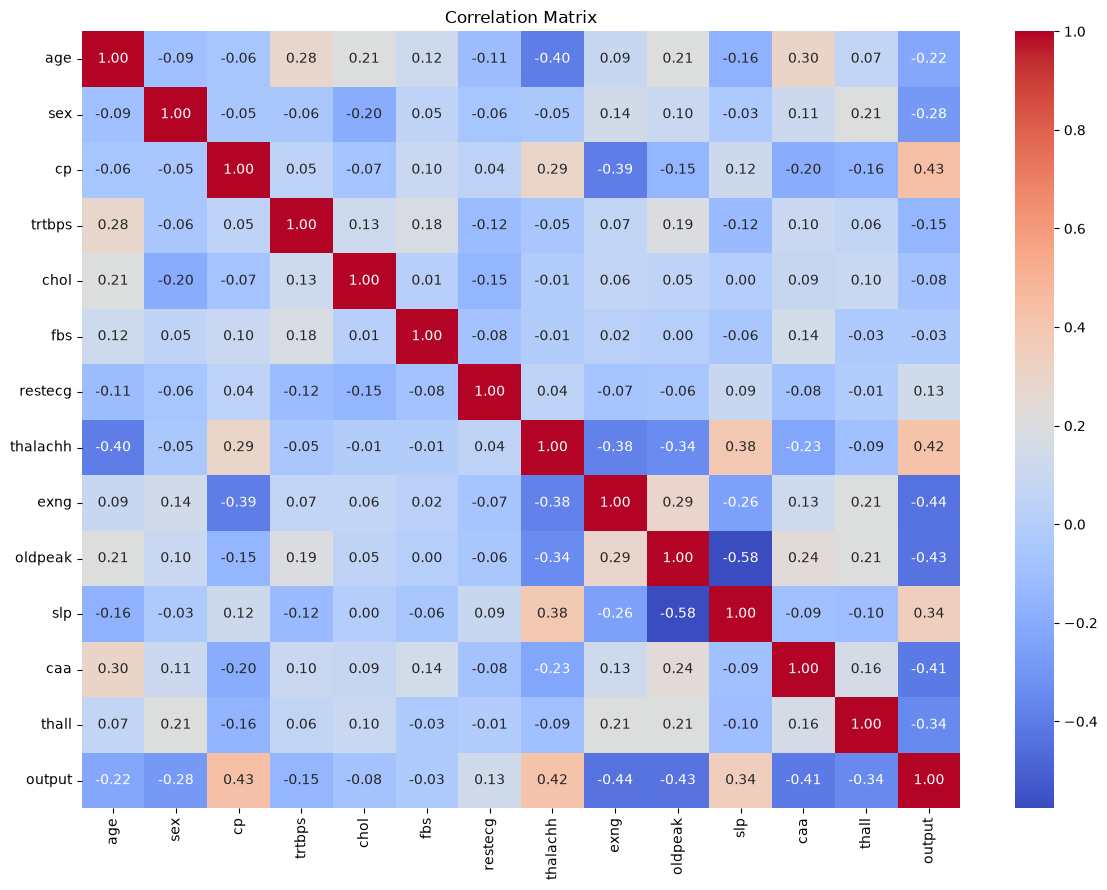

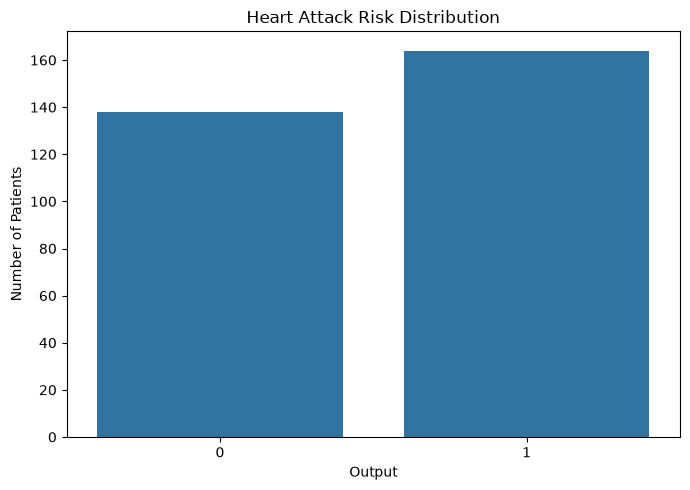

In [89]:
# ============================================================
# 5. Exploratory data analysis
# ============================================================

display(df.describe())

plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_matrix.png"), dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x="output", data=df)
plt.title("Heart Attack Risk Distribution")
plt.xlabel("Output")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "target_distribution.png"), dpi=300)
plt.show()


In [90]:
# ============================================================
# 6. 60/20/20 train-validation-test split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training:", X_train.shape[0], f"({X_train.shape[0] / len(df) * 100:.1f}%)")
print("Validation:", X_val.shape[0], f"({X_val.shape[0] / len(df) * 100:.1f}%)")
print("Test:", X_test.shape[0], f"({X_test.shape[0] / len(df) * 100:.1f}%)")


Training: 181 (59.9%)
Validation: 60 (19.9%)
Test: 61 (20.2%)


In [91]:
# ============================================================
# 7. Scaling
# ============================================================

# Standard scaling for PCA/clustering.
standard_scaler = StandardScaler()
X_scaled_all = standard_scaler.fit_transform(X)

# Min-max scaling for SVM and Elastic Net, following the paper's
# statement that data were min-max scaled before these models.
minmax_scaler = MinMaxScaler()

X_train_scaled = minmax_scaler.fit_transform(X_train)
X_val_scaled = minmax_scaler.transform(X_val)
X_test_scaled = minmax_scaler.transform(X_test)

print("Scaling complete.")


Scaling complete.


,PCA_Components,Cumulative_Explained_Variance
0,1,0.213135
1,2,0.331730
2,3,0.425328
3,4,0.516539
4,5,0.595242
5,6,0.669802
6,7,0.736344
7,8,0.796308
8,9,0.850633
9,10,0.898512


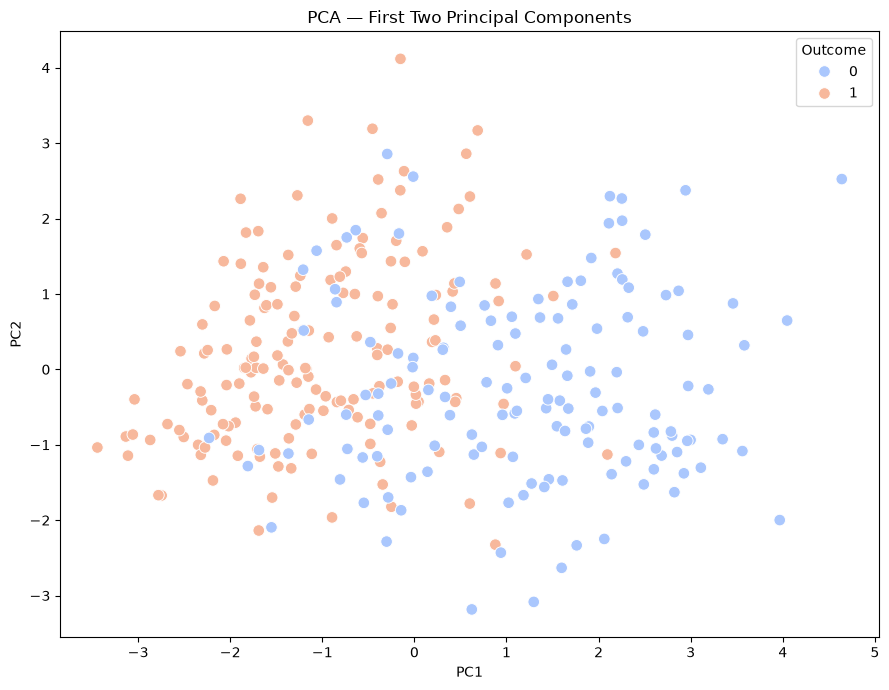

In [92]:
# ============================================================
# 8. PCA
# ============================================================

pca_summary = []

max_components = min(10, X_scaled_all.shape[1])

for n_components in range(1, max_components + 1):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca.fit(X_scaled_all)
    pca_summary.append({
        "PCA_Components": n_components,
        "Cumulative_Explained_Variance": pca.explained_variance_ratio_.sum()
    })

pca_summary_df = pd.DataFrame(pca_summary)
display(pca_summary_df)

pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_scaled_all)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "Outcome": y.values
})

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="coolwarm",
    s=70
)
plt.title("PCA — First Two Principal Components")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pca_outcome.png"), dpi=300)
plt.show()


,PCA_Components,ARI
0,1,0.360968
1,2,0.377044
2,3,0.368910
3,4,0.368930
4,5,0.385265
5,6,0.385265
6,7,0.402012
7,8,0.385265
8,9,0.393614
9,10,0.402012


Best K-Means ARI: 0.4020 using 7 PCA components.


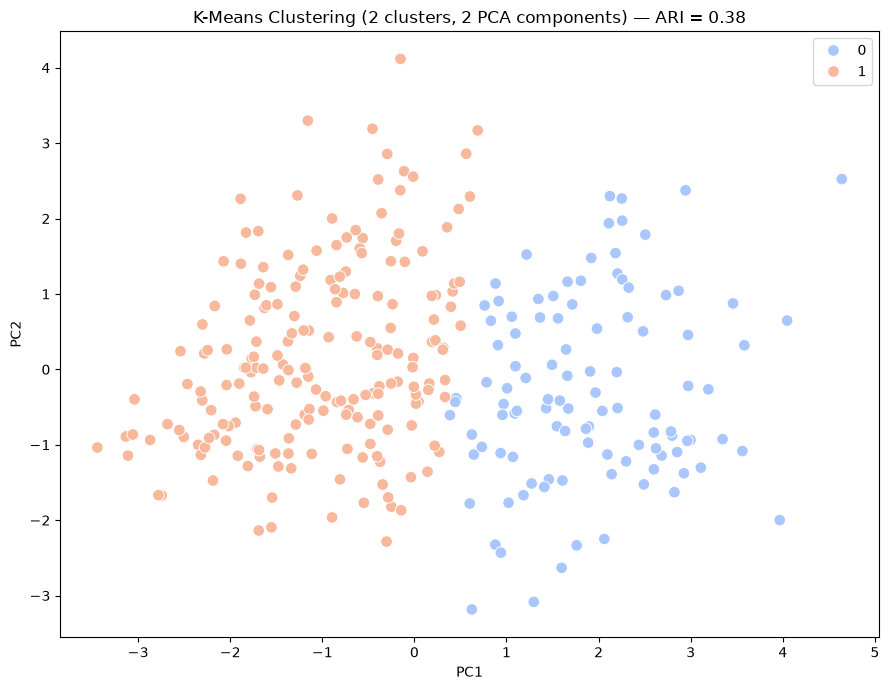

In [93]:
# ============================================================
# 9. K-Means clustering + ARI
# ============================================================

kmeans_results = []

for n_components in range(1, max_components + 1):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled_all)

    kmeans = KMeans(
        n_clusters=2,
        random_state=RANDOM_STATE,
        n_init=10
    )
    clusters = kmeans.fit_predict(X_pca)

    kmeans_results.append({
        "PCA_Components": n_components,
        "ARI": adjusted_rand_score(y, clusters)
    })

kmeans_df = pd.DataFrame(kmeans_results)
display(kmeans_df)

best_kmeans_row = kmeans_df.loc[kmeans_df["ARI"].idxmax()]
print(
    f"Best K-Means ARI: {best_kmeans_row['ARI']:.4f} "
    f"using {int(best_kmeans_row['PCA_Components'])} PCA components."
)

kmeans_2 = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)
kmeans_clusters_2 = kmeans_2.fit_predict(X_pca_2)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_pca_2[:, 0],
    y=X_pca_2[:, 1],
    hue=kmeans_clusters_2,
    palette="coolwarm",
    s=70
)
plt.title(
    f"K-Means Clustering (2 clusters, 2 PCA components) — "
    f"ARI = {adjusted_rand_score(y, kmeans_clusters_2):.2f}"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kmeans_clustering.png"), dpi=300)
plt.show()


,Epsilon,ARI,Number_of_Clusters_Including_Noise
0,1,0.002583,2
1,2,0.000000,1
2,3,0.000000,1
3,4,0.000000,1
4,5,0.000000,1
5,6,0.000000,1
6,7,0.000000,1
7,8,0.000000,1
8,9,0.000000,1
9,10,0.000000,1


Best DBSCAN ARI in this search: 0.0026 at epsilon=1.0


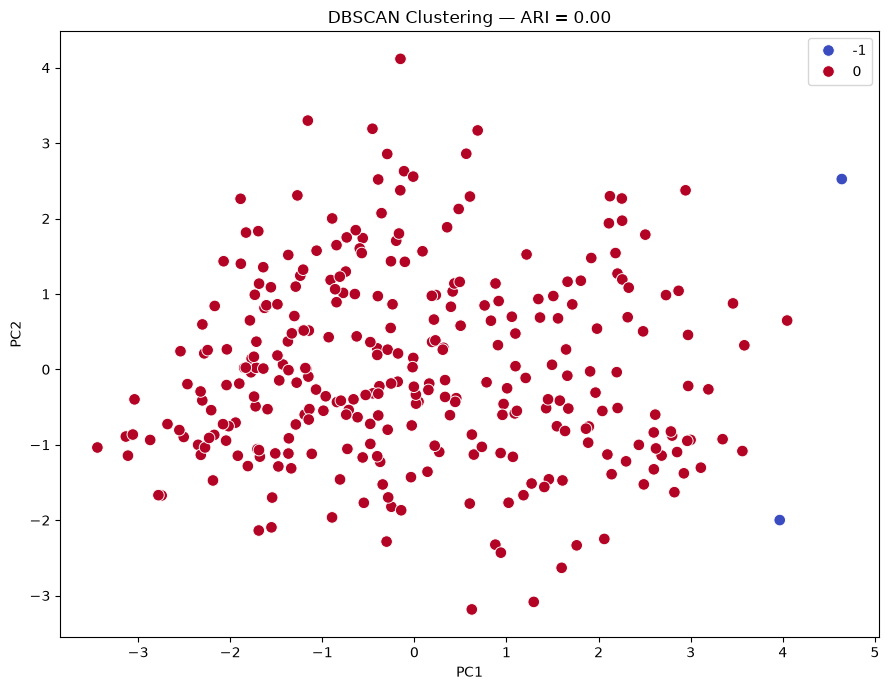

In [94]:
# ============================================================
# 10. DBSCAN clustering + ARI
# ============================================================

dbscan_results = []

# The paper reports an epsilon of 1.0 in its clustering description.
# We evaluate epsilon values 1..10 here so the result can be inspected.
for eps in range(1, 11):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(X_pca_2)

    dbscan_results.append({
        "Epsilon": eps,
        "ARI": adjusted_rand_score(y, clusters),
        "Number_of_Clusters_Including_Noise": len(set(clusters))
    })

dbscan_df = pd.DataFrame(dbscan_results)
display(dbscan_df)

best_dbscan_row = dbscan_df.loc[dbscan_df["ARI"].idxmax()]
best_dbscan_eps = float(best_dbscan_row["Epsilon"])

print(
    f"Best DBSCAN ARI in this search: {best_dbscan_row['ARI']:.4f} "
    f"at epsilon={best_dbscan_eps}"
)

best_dbscan = DBSCAN(eps=best_dbscan_eps, min_samples=5)
dbscan_clusters = best_dbscan.fit_predict(X_pca_2)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_pca_2[:, 0],
    y=X_pca_2[:, 1],
    hue=dbscan_clusters,
    palette="coolwarm",
    s=70
)
plt.title(
    f"DBSCAN Clustering — ARI = "
    f"{adjusted_rand_score(y, dbscan_clusters):.2f}"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dbscan_clustering.png"), dpi=300)
plt.show()


In [95]:
# ============================================================
# 11. Cross-validation and metric helper
# ============================================================

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=RANDOM_STATE
)

def calculate_classification_metrics(model, X_data, y_data):
    predictions = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_data)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
    else:
        scores = predictions

    return {
        "AUROC": roc_auc_score(y_data, scores),
        "Precision": precision_score(y_data, predictions, zero_division=0),
        "Recall": recall_score(y_data, predictions, zero_division=0),
        "F1": f1_score(y_data, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_data, predictions),
    }

print("Metric helper and repeated 10-fold CV are ready.")


Metric helper and repeated 10-fold CV are ready.


In [96]:
# ============================================================
# 12. Logistic Regression
# ============================================================

logistic = LogisticRegression(
    max_iter=10000,
    random_state=RANDOM_STATE
)

logistic_params = {
    "C": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    "solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    logistic,
    logistic_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

logistic_grid.fit(X_train_scaled, y_train)
best_logistic = logistic_grid.best_estimator_

logistic_val_metrics = calculate_classification_metrics(
    best_logistic, X_val_scaled, y_val
)

print("Best parameters:", logistic_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in logistic_val_metrics.items()})


Best parameters: {'C': 10.0, 'solver': 'lbfgs'}
Validation metrics: {'AUROC': 0.8765, 'Precision': 0.7143, 'Recall': 0.9091, 'F1': 0.8, 'Accuracy': 0.75}


In [100]:
# ============================================================
# 13. Gradient Boosting
# ============================================================

gbm = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

gbm_params = {
    "learning_rate": [0.05, 0.1, 0.25],
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4]
}

gbm_grid = GridSearchCV(
    estimator=gbm,
    param_grid=gbm_params,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gbm_grid.fit(X_train, y_train)

best_gbm = gbm_grid.best_estimator_

gbm_val_metrics = calculate_classification_metrics(
    best_gbm,
    X_val,
    y_val
)

print("Best parameters:", gbm_grid.best_params_)
print(
    "Validation metrics:",
    {k: round(v, 4) for k, v in gbm_val_metrics.items()}
)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Validation metrics: {'AUROC': 0.8676, 'Precision': 0.8108, 'Recall': 0.9091, 'F1': 0.8571, 'Accuracy': 0.8333}


In [101]:
# ============================================================
# 14. SVM — Linear
# ============================================================

svm_linear = SVC(
    kernel="linear",
    probability=True,
    random_state=RANDOM_STATE
)

svm_linear_params = {
    "C": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000]
}

svm_linear_grid = GridSearchCV(
    svm_linear,
    svm_linear_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

svm_linear_grid.fit(X_train_scaled, y_train)
best_svm_linear = svm_linear_grid.best_estimator_

svm_linear_val_metrics = calculate_classification_metrics(
    best_svm_linear, X_val_scaled, y_val
)

print("Best parameters:", svm_linear_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in svm_linear_val_metrics.items()})


Best parameters: {'C': 10}
Validation metrics: {'AUROC': 0.8631, 'Precision': 0.7381, 'Recall': 0.9394, 'F1': 0.8267, 'Accuracy': 0.7833}


In [102]:
# ============================================================
# 15. SVM — RBF
# ============================================================

svm_rbf = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

svm_rbf_params = {
    "C": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000],
    "gamma": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000]
}

svm_rbf_grid = GridSearchCV(
    svm_rbf,
    svm_rbf_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

svm_rbf_grid.fit(X_train_scaled, y_train)
best_svm_rbf = svm_rbf_grid.best_estimator_

svm_rbf_val_metrics = calculate_classification_metrics(
    best_svm_rbf, X_val_scaled, y_val
)

print("Best parameters:", svm_rbf_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in svm_rbf_val_metrics.items()})


Best parameters: {'C': 10, 'gamma': 0.1}
Validation metrics: {'AUROC': 0.8698, 'Precision': 0.725, 'Recall': 0.8788, 'F1': 0.7945, 'Accuracy': 0.75}


In [103]:
# ============================================================
# 16. SVM — Polynomial
# ============================================================

svm_poly = SVC(
    kernel="poly",
    probability=True,
    random_state=RANDOM_STATE
)

svm_poly_params = {
    "C": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000],
    "degree": [2, 3, 4, 5, 6]
}

svm_poly_grid = GridSearchCV(
    svm_poly,
    svm_poly_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

svm_poly_grid.fit(X_train_scaled, y_train)
best_svm_poly = svm_poly_grid.best_estimator_

svm_poly_val_metrics = calculate_classification_metrics(
    best_svm_poly, X_val_scaled, y_val
)

print("Best parameters:", svm_poly_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in svm_poly_val_metrics.items()})


Best parameters: {'C': 1, 'degree': 2}
Validation metrics: {'AUROC': 0.8575, 'Precision': 0.7692, 'Recall': 0.9091, 'F1': 0.8333, 'Accuracy': 0.8}


In [104]:
# ============================================================
# 17. Elastic Net
# ============================================================
# The paper lists Elastic Net among its supervised models but
# does not specify enough implementation detail to reproduce
# its exact binary-classification implementation.
#
# We therefore use sklearn ElasticNet as a continuous score
# model and threshold its score at 0.5 for class predictions.
# This is an explicit reproduction assumption.

elastic = ElasticNet(
    max_iter=100000,
    random_state=RANDOM_STATE
)

elastic_params = {
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    "l1_ratio": [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
}

elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

elastic_grid.fit(X_train_scaled, y_train)
best_elastic = elastic_grid.best_estimator_

elastic_val_scores = best_elastic.predict(X_val_scaled)
elastic_val_predictions = (elastic_val_scores >= 0.5).astype(int)

elastic_val_metrics = {
    "AUROC": roc_auc_score(y_val, elastic_val_scores),
    "Precision": precision_score(y_val, elastic_val_predictions, zero_division=0),
    "Recall": recall_score(y_val, elastic_val_predictions, zero_division=0),
    "F1": f1_score(y_val, elastic_val_predictions, zero_division=0),
    "Accuracy": accuracy_score(y_val, elastic_val_predictions),
}

print("Best parameters:", elastic_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in elastic_val_metrics.items()})


Best parameters: {'alpha': 0.01, 'l1_ratio': 0.1}
Validation metrics: {'AUROC': 0.8743, 'Precision': 0.7381, 'Recall': 0.9394, 'F1': 0.8267, 'Accuracy': 0.7833}


In [105]:
# ============================================================
# 18. Bagging
# ============================================================

bagging = BaggingClassifier(
    random_state=RANDOM_STATE
)

bagging_params = {
    "n_estimators": [10, 50, 100, 300, 500, 700, 1000],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0]
}

bagging_grid = GridSearchCV(
    bagging,
    bagging_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)
best_bagging = bagging_grid.best_estimator_

bagging_val_metrics = calculate_classification_metrics(
    best_bagging, X_val, y_val
)

print("Best parameters:", bagging_grid.best_params_)
print("Validation metrics:", {k: round(v, 4) for k, v in bagging_val_metrics.items()})


Best parameters: {'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 500}
Validation metrics: {'AUROC': 0.853, 'Precision': 0.7692, 'Recall': 0.9091, 'F1': 0.8333, 'Accuracy': 0.8}


In [107]:
# ============================================================
# ============================================================
# 19. Random Forest
# ============================================================

rf = RandomForestClassifier(
    random_state=RANDOM_STATE
)

rf_params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_val_metrics = calculate_classification_metrics(
    best_rf,
    X_val,
    y_val
)

print("Best parameters:", rf_grid.best_params_)
print(
    "Validation metrics:",
    {k: round(v, 4) for k, v in rf_val_metrics.items()}
)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Validation metrics: {'AUROC': 0.8664, 'Precision': 0.7692, 'Recall': 0.9091, 'F1': 0.8333, 'Accuracy': 0.8}


In [108]:
# ============================================================
# 20. Neural Network
# ============================================================
# Reference architecture described in the paper:
# 4 hidden layers: 18, 15, 10, 8 neurons
# ReLU activation
# 150 epochs
# 10 samples per batch
#
# sklearn's MLPClassifier uses max_iter as the maximum number
# of training iterations. It may stop earlier if convergence
# is reached.

nn_model = MLPClassifier(
    hidden_layer_sizes=(18, 15, 10, 8),
    activation="relu",
    solver="adam",
    batch_size=10,
    max_iter=150,
    random_state=RANDOM_STATE
)

nn_model.fit(X_train_scaled, y_train)

nn_val_metrics = calculate_classification_metrics(
    nn_model, X_val_scaled, y_val
)

print("Validation metrics:", {k: round(v, 4) for k, v in nn_val_metrics.items()})


Validation metrics: {'AUROC': 0.8575, 'Precision': 0.7297, 'Recall': 0.8182, 'F1': 0.7714, 'Accuracy': 0.7333}


In [110]:
# ============================================================
# 21. Validation results table
# ============================================================

validation_results = {
    "Logistic Regression": logistic_val_metrics,
    "Gradient Boosting": gbm_val_metrics,
    "SVM Linear": svm_linear_val_metrics,
    "SVM RBF": svm_rbf_val_metrics,
    "SVM Polynomial": svm_poly_val_metrics,
    "Elastic Net": elastic_val_metrics,
    "Bagging": bagging_val_metrics,
    "Random Forest": rf_val_metrics,
    "Neural Network": nn_val_metrics,
}

validation_table = pd.DataFrame(validation_results).T[
    ["AUROC", "Precision", "Recall", "F1", "Accuracy"]
].sort_values("F1", ascending=False)

display(validation_table.round(4))

validation_table.to_csv(
    os.path.join(RESULTS_DIR, "validation_results.csv")
)

print("Validation results saved.")


,AUROC,Precision,Recall,F1,Accuracy
Gradient Boosting,0.8676,0.8108,0.9091,0.8571,0.8333
Random Forest,0.8664,0.7692,0.9091,0.8333,0.8000
SVM Polynomial,0.8575,0.7692,0.9091,0.8333,0.8000
Bagging,0.8530,0.7692,0.9091,0.8333,0.8000
Elastic Net,0.8743,0.7381,0.9394,0.8267,0.7833
SVM Linear,0.8631,0.7381,0.9394,0.8267,0.7833
Logistic Regression,0.8765,0.7143,0.9091,0.8000,0.7500
SVM RBF,0.8698,0.7250,0.8788,0.7945,0.7500
Neural Network,0.8575,0.7297,0.8182,0.7714,0.7333


Validation results saved.


In [112]:
# ============================================================
# 22. Test-set evaluation
# ============================================================

model_objects = {
    "Logistic Regression": (best_logistic, X_test_scaled),
    "Gradient Boosting": (best_gbm, X_test),
    "SVM Linear": (best_svm_linear, X_test_scaled),
    "SVM RBF": (best_svm_rbf, X_test_scaled),
    "SVM Polynomial": (best_svm_poly, X_test_scaled),
    "Elastic Net": (best_elastic, X_test_scaled),
    "Bagging": (best_bagging, X_test),
    "Random Forest": (best_rf, X_test),
    "Neural Network": (nn_model, X_test_scaled),
}

test_results = {}

for model_name, (model, test_data) in model_objects.items():

    # Elastic Net produces continuous values,
    # so handle it separately.
    if model_name == "Elastic Net":

        test_scores = model.predict(test_data)
        test_predictions = (test_scores >= 0.5).astype(int)

        test_results[model_name] = {
            "AUROC": roc_auc_score(y_test, test_scores),
            "Precision": precision_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_test,
                test_predictions,
                zero_division=0
            ),
            "Accuracy": accuracy_score(
                y_test,
                test_predictions
            )
        }

    else:

        test_results[model_name] = calculate_classification_metrics(
            model,
            test_data,
            y_test
        )

test_table = pd.DataFrame(test_results).T[
    ["AUROC", "Precision", "Recall", "F1", "Accuracy"]
]

display(test_table.round(4))

test_table.to_csv(
    os.path.join(RESULTS_DIR, "test_results.csv")
)

print("Test results saved successfully.")

,AUROC,Precision,Recall,F1,Accuracy
Logistic Regression,0.9340,0.8056,0.8788,0.8406,0.8197
Gradient Boosting,0.9242,0.8056,0.8788,0.8406,0.8197
SVM Linear,0.9318,0.8333,0.9091,0.8696,0.8525
SVM RBF,0.9264,0.8205,0.9697,0.8889,0.8689
SVM Polynomial,0.9210,0.8205,0.9697,0.8889,0.8689
Elastic Net,0.9221,0.8205,0.9697,0.8889,0.8689
Bagging,0.9253,0.7895,0.9091,0.8451,0.8197
Random Forest,0.9264,0.7895,0.9091,0.8451,0.8197
Neural Network,0.9113,0.8000,0.8485,0.8235,0.8033


Test results saved successfully.


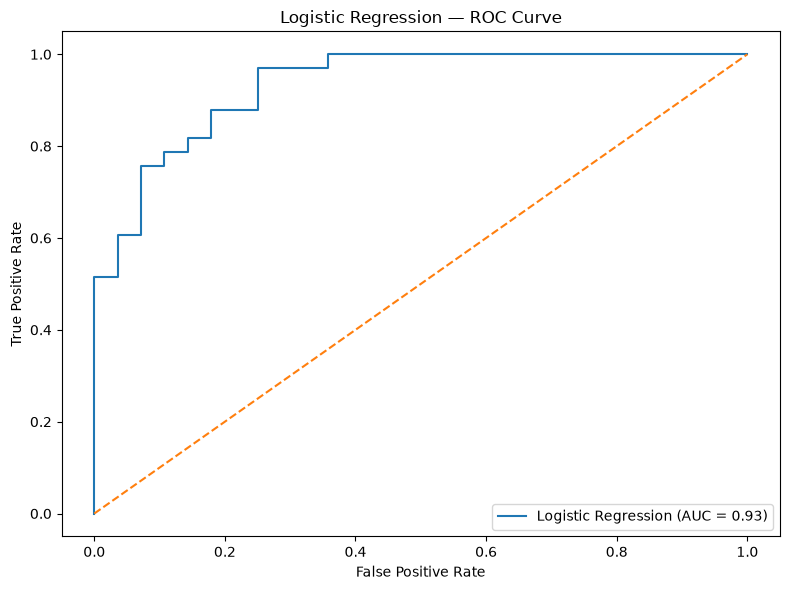

In [113]:
# ============================================================
# 23. Logistic Regression ROC curve
# ============================================================

logistic_test_probabilities = best_logistic.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, logistic_test_probabilities)
logistic_auc = roc_auc_score(y_test, logistic_test_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.2f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "logistic_regression_roc.png"),
    dpi=300
)
plt.show()


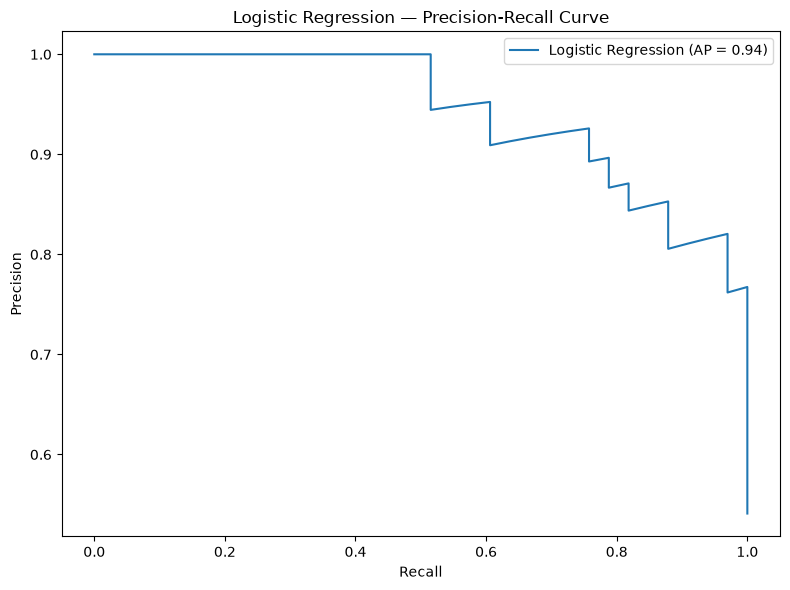

In [114]:
# ============================================================
# 24. Logistic Regression Precision-Recall curve
# ============================================================

precision, recall, _ = precision_recall_curve(
    y_test,
    logistic_test_probabilities
)

average_precision = average_precision_score(
    y_test,
    logistic_test_probabilities
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision:.2f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression — Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "logistic_regression_pr_curve.png"),
    dpi=300
)
plt.show()


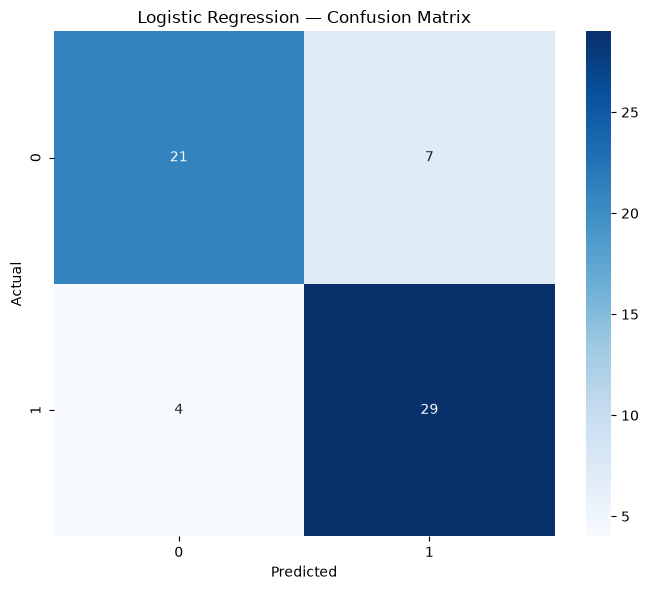

In [115]:
# ============================================================
# 25. Logistic Regression confusion matrix
# ============================================================

logistic_test_predictions = best_logistic.predict(X_test_scaled)

cm = confusion_matrix(y_test, logistic_test_predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "logistic_confusion_matrix.png"),
    dpi=300
)
plt.show()


In [116]:
# ============================================================
# 26. Reported results from the reference paper
# ============================================================

reported_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting",
        "SVM RBF",
        "Bagging",
        "Random Forest"
    ],
    "Reported_Test_AUROC": [0.86, 0.83, 0.50, 0.80, 0.78],
    "Reported_Test_Precision": [0.84, 0.81, 0.00, 0.78, 0.78],
    "Reported_Test_Recall": [0.94, 0.91, 0.00, 0.88, 0.85],
    "Reported_Test_F1": [0.89, 0.86, 0.00, 0.83, 0.81],
    "Reported_Test_Accuracy": [0.87, 0.84, 0.46, 0.80, 0.79],
})

display(reported_results)

reported_results.to_csv(
    os.path.join(RESULTS_DIR, "reported_results.csv"),
    index=False
)


,Model,Reported_Test_AUROC,Reported_Test_Precision,Reported_Test_Recall,Reported_Test_F1,Reported_Test_Accuracy
0,Logistic Regression,0.86,0.84,0.94,0.89,0.87
1,Gradient Boosting,0.83,0.81,0.91,0.86,0.84
2,SVM RBF,0.50,0.00,0.00,0.00,0.46
3,Bagging,0.80,0.78,0.88,0.83,0.80
4,Random Forest,0.78,0.78,0.85,0.81,0.79


In [117]:
# ============================================================
# 27. Reported vs. reproduced comparison
# ============================================================

comparison_rows = []

for _, row in reported_results.iterrows():
    model_name = row["Model"]

    if model_name in test_table.index:
        reproduced = test_table.loc[model_name]

        comparison_rows.append({
            "Model": model_name,
            "Reported AUROC": row["Reported_Test_AUROC"],
            "Our AUROC": reproduced["AUROC"],
            "Reported Precision": row["Reported_Test_Precision"],
            "Our Precision": reproduced["Precision"],
            "Reported Recall": row["Reported_Test_Recall"],
            "Our Recall": reproduced["Recall"],
            "Reported F1": row["Reported_Test_F1"],
            "Our F1": reproduced["F1"],
            "Reported Accuracy": row["Reported_Test_Accuracy"],
            "Our Accuracy": reproduced["Accuracy"],
        })

comparison_table = pd.DataFrame(comparison_rows)

display(comparison_table.round(4))

comparison_table.to_csv(
    os.path.join(RESULTS_DIR, "reported_vs_reproduced.csv"),
    index=False
)


,Model,Reported AUROC,Our AUROC,Reported Precision,Our Precision,Reported Recall,Our Recall,Reported F1,Our F1,Reported Accuracy,Our Accuracy
0,Logistic Regression,0.86,0.9340,0.84,0.8056,0.94,0.8788,0.89,0.8406,0.87,0.8197
1,Gradient Boosting,0.83,0.9242,0.81,0.8056,0.91,0.8788,0.86,0.8406,0.84,0.8197
2,SVM RBF,0.50,0.9264,0.00,0.8205,0.00,0.9697,0.00,0.8889,0.46,0.8689
3,Bagging,0.80,0.9253,0.78,0.7895,0.88,0.9091,0.83,0.8451,0.80,0.8197
4,Random Forest,0.78,0.9264,0.78,0.7895,0.85,0.9091,0.81,0.8451,0.79,0.8197


In [118]:
# ============================================================
# 28. Difference table
# ============================================================

difference_table = comparison_table.copy()

difference_table["AUROC Difference"] = (
    difference_table["Our AUROC"] - difference_table["Reported AUROC"]
)
difference_table["Precision Difference"] = (
    difference_table["Our Precision"] - difference_table["Reported Precision"]
)
difference_table["Recall Difference"] = (
    difference_table["Our Recall"] - difference_table["Reported Recall"]
)
difference_table["F1 Difference"] = (
    difference_table["Our F1"] - difference_table["Reported F1"]
)
difference_table["Accuracy Difference"] = (
    difference_table["Our Accuracy"] - difference_table["Reported Accuracy"]
)

display(difference_table.round(4))

difference_table.to_csv(
    os.path.join(RESULTS_DIR, "result_differences.csv"),
    index=False
)


,Model,Reported AUROC,Our AUROC,Reported Precision,Our Precision,Reported Recall,Our Recall,Reported F1,Our F1,Reported Accuracy,Our Accuracy,AUROC Difference,Precision Difference,Recall Difference,F1 Difference,Accuracy Difference
0,Logistic Regression,0.86,0.9340,0.84,0.8056,0.94,0.8788,0.89,0.8406,0.87,0.8197,0.0740,-0.0344,-0.0612,-0.0494,-0.0503
1,Gradient Boosting,0.83,0.9242,0.81,0.8056,0.91,0.8788,0.86,0.8406,0.84,0.8197,0.0942,-0.0044,-0.0312,-0.0194,-0.0203
2,SVM RBF,0.50,0.9264,0.00,0.8205,0.00,0.9697,0.00,0.8889,0.46,0.8689,0.4264,0.8205,0.9697,0.8889,0.4089
3,Bagging,0.80,0.9253,0.78,0.7895,0.88,0.9091,0.83,0.8451,0.80,0.8197,0.1253,0.0095,0.0291,0.0151,0.0197
4,Random Forest,0.78,0.9264,0.78,0.7895,0.85,0.9091,0.81,0.8451,0.79,0.8197,0.1464,0.0095,0.0591,0.0351,0.0297


## Final interpretation

Do **not** manually change your reproduced results to match the reference paper.

Small differences are acceptable. The reference paper states that the data were randomly split into 60% training, 20% validation and 20% test sets and used repeated 10-fold cross-validation for model tuning, but it does not provide every implementation detail needed to guarantee identical numbers.

If your results differ, document possible reasons such as:

- different random seed or train/validation/test partition
- missing hyperparameters in the reference
- implementation differences
- scikit-learn / Python library version differences
- differences in preprocessing
- differences in the exact publicly available dataset file

In [119]:
# ============================================================
# 29. Final summary
# ============================================================

print("=" * 70)
print("PART 1 REPRODUCTION COMPLETE")
print("=" * 70)

print("\nBest model by OUR validation F1:")
print(validation_table.index[0])

print(
    "Validation F1:",
    round(validation_table.iloc[0]["F1"], 4)
)

print("\nTest models evaluated:")
print(test_table.index.tolist())

print("\nResults folder:")
print(os.path.abspath(RESULTS_DIR))

print("\nGenerated result files:")
for filename in sorted(os.listdir(RESULTS_DIR)):
    print(" -", filename)


PART 1 REPRODUCTION COMPLETE

Best model by OUR validation F1:
Gradient Boosting
Validation F1: 0.8571

Test models evaluated:
['Logistic Regression', 'Gradient Boosting', 'SVM Linear', 'SVM RBF', 'SVM Polynomial', 'Elastic Net', 'Bagging', 'Random Forest', 'Neural Network']

Results folder:
c:\Users\adars\OneDrive\Desktop\heart-attack-ml-project\notebooks\results

Generated result files:
 - correlation_matrix.png
 - dbscan_clustering.png
 - kmeans_clustering.png
 - logistic_confusion_matrix.png
 - logistic_regression_pr_curve.png
 - logistic_regression_roc.png
 - pca_outcome.png
 - reported_results.csv
 - reported_vs_reproduced.csv
 - result_differences.csv
 - target_distribution.png
 - test_results.csv
 - validation_results.csv
